# **CS 5365 Deep Learning - Classifying the MNIST dataset**
**Author:** Miguel Lucero<br>
Computer Science Department<br>
University of Texas at El Paso<br>


**Classifying the MNIST dataset**

Implement the techniques mentioned below using tensorflow and train and evaluate your models. Show the train and test set accuracies and the test set confusion matrix.





# Loading and preprocessing the data

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, confusion_matrix
import time
from keras import activations
from keras.layers import *
from keras.utils import plot_model

(X_train, y_train), (X_test, y_test) = tf.keras.datasets.mnist.load_data()

In [ ]:
print(f'{X_train.shape=}')
print(f'{X_test.shape=}')
print(f'{y_train.shape=}')
print(f'{y_test.shape=}')

X_train.shape=(60000, 28, 28)
X_test.shape=(10000, 28, 28)
y_train.shape=(60000,)
y_test.shape=(10000,)


Class: 5


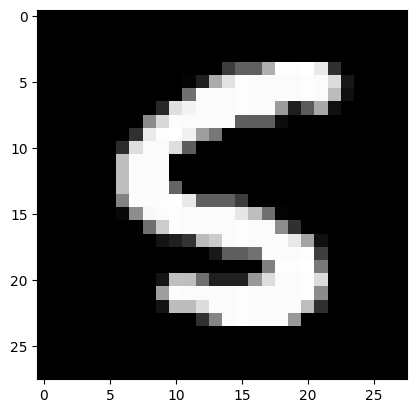

000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 
000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 
000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 
000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 
000 000 000 000 000 000 000 000 000 000 000 000 000 000 060 096 096 174 253 253 255 233 048 000 000 000 000 000 
000 000 000 000 000 000 000 000 000 000 000 004 032 171 228 253 251 251 251 251 253 251 220 023 000 000 000 000 
000 000 000 000 000 000 000 000 000 000 000 112 251 251 251 253 251 251 251 251 253 251 188 015 000 000 000 000 
000 000 000 000 000 000 000 000 000 040 223 244 251 251 251 253 251 251 156 031 091 168 015 000 000 000 000 000 
000 000 000 000 000 000 000 000 139 217 253 251 251 251 251 095 094 094 012 000 000 000 000 000 

In [ ]:
im = np.random.randint(0,X_train.shape[0])
plt.imshow(X_train[im],cmap='gray')
print('Class:',y_train[im])
plt.show()

for i in range(28):
    for j in range(28):
        print(str(np.int16(X_train[im,i,j])+1000)[1:],end=' ')
    print()

Showing some more examples.

Class: 0


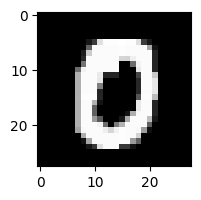

Class: 1


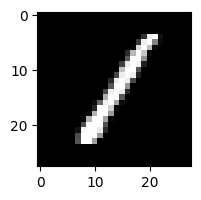

Class: 1


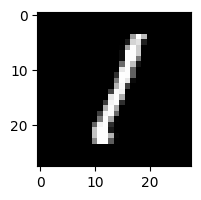

Class: 2


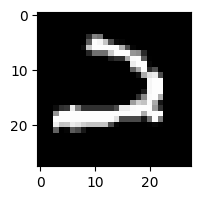

Class: 3


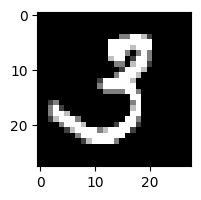

In [ ]:
for i in range(5):
  im = np.random.randint(0,X_train.shape[0])
  plt.figure(figsize=(2,2))
  plt.imshow(X_train[im],cmap='gray')
  print('Class:',y_train[im])
  plt.show()

## Pre-processing

We convert the 3D train and test datasets to 2D arrays by concatetnating all pixels values in an image to a single row. We also convert to floating point. We convert the class to a one_hot representation (i.e. 1 becomes [0,1,0,0,0,0,0,0,0,0]).

In [ ]:
X_train = np.float32(X_train.reshape(X_train.shape[0],-1))/255
X_test = np.float32(X_test.reshape(X_test.shape[0],-1))/255
y_train_oh = tf.keras.utils.to_categorical(y_train, 10)
y_test_oh = tf.keras.utils.to_categorical(y_test, 10)
print(f'{X_train.shape=}')
print(f'{X_test.shape=}')
print(f'{y_train.shape=}')
print(f'{y_test.shape=}')
print(f'{y_train_oh.shape=}')
print(f'{y_test_oh.shape=}')

y_train_oh = tf.keras.utils.to_categorical(y_train, 10)
y_test_oh = tf.keras.utils.to_categorical(y_test, 10)

X_train.shape=(60000, 784)
X_test.shape=(10000, 784)
y_train.shape=(60000,)
y_test.shape=(10000,)
y_train_oh.shape=(60000, 10)
y_test_oh.shape=(10000, 10)


# Classification using linear regression

In [ ]:
model = tf.keras.models.Sequential()
model.add(Input((X_train.shape[1],)))
model.add(Dense(y_test_oh.shape[1]))

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.1), loss="mse")
model.summary()

history = model.fit(X_train, y_train_oh, epochs = 10, batch_size = 100, verbose = 2)

pred = model.predict(X_test)
pred_classes = np.argmax(pred, axis=1)
print(f'Confusion matrix:\n{confusion_matrix(y_test, pred_classes)}')
print(f'Accuracy: {accuracy_score(y_test, pred_classes):6.4f}')

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 10)             │         7,850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,850 (30.66 KB)

 Trainable params: 7,850 (30.66 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
600/600 - 1s - 2ms/step - loss: 0.7289
Epoch 2/10
600/600 - 1s - 2ms/step - loss: 0.1332
Epoch 3/10
600/600 - 2s - 3ms/step - loss: 0.2667
Epoch 4/10
600/600 - 1s - 2ms/step - loss: 0.2715
Epoch 5/10
600/600 - 2s - 4ms/step - loss: 0.3296
Epoch 6/10
600/600 - 1s - 2ms/step - loss: 0.3481
Epoch 7/10
600/600 - 1s - 2ms/step - loss: 0.2901
Epoch 8/10
600/600 - 2s - 4ms/step - loss: 0.2872
Epoch 9/10
600/600 - 2s - 3ms/step - loss: 0.3234
Epoch 10/10
600/600 - 3s - 5ms/step - loss: 0.2964
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Confusion matrix:
[[932   4   1  20   0   5  14   0   4   0]
 [ 26 741   3 237  37  40   4   9  38   0]
 [364  42 155 273  12  15  48  26  97   0]
 [189   7   1 653  10  16  15  23  91   5]
 [207  32   6 106 476   8  53  18  62  14]
 [288  24   2  63  11 353  44   4  97   6]
 [348  35   6  18  20  18 508   2   2   1]
 [303  77   9  76   8  20  59 395  26  55]
 [165  13   0  62  16  84  24   1 606   3]
 [229  15   0  77  36  18  67  39 248 280]]
Accuracy:

In [ ]:
#Sklearn version
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score
from sklearn.linear_model import LinearRegression
linear_regressor = LinearRegression()
start = time.time()
linear_regressor.fit(X_train, y_train_oh)
end = time.time()
print('Elapsed time training= {:.4f} secs'.format(end-start))
start = time.time()
pred = linear_regressor.predict(X_test)
end = time.time()
print('Elapsed time testing= {:.4f} secs'.format(end-start))

pred_classes = np.argmax(pred, axis=1)

print(f'Confusion matrix:\n{confusion_matrix(y_test, pred_classes)}')
print(f'Accuracy: {accuracy_score(y_test, pred_classes):6.4f}')
print(f'Precision: {precision_score(y_test, pred_classes, average="macro"):6.4f}')
print(f'Recall: {recall_score(y_test, pred_classes, average="macro"):6.4f}')
print(f'F1: {f1_score(y_test, pred_classes, average="macro"):6.4f}')

Elapsed time training= 11.0354 secs
Elapsed time testing= 0.0290 secs
Confusion matrix:
[[ 943    0    2    2    2    8   13    2    7    1]
 [   0 1107    2    2    3    1    5    1   14    0]
 [  18   53  812   26   17    0   43   20   38    5]
 [   4   18   21  884    5   16    9   20   22   11]
 [   0   22    7    0  880    5   11    2   11   44]
 [  23   18    3   75   23  660   23   13   38   16]
 [  18   10   10    0   21   17  875    0    7    0]
 [   5   42   15    6   26    0    1  882    0   51]
 [  14   46   11   31   28   41   15   11  758   19]
 [  16   11    3   17   79    0    1   78    4  800]]
Accuracy: 0.8601
Precision: 0.8622
Recall: 0.8578
F1: 0.8578


# Classification using logistic regression

In [ ]:
model = tf.keras.models.Sequential()
model.add(Input((X_train.shape[1],)))
model.add(Dense(y_test_oh.shape[1], activation="softmax"))

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.1), loss="categorical_crossentropy")
model.summary()

history = model.fit(X_train, y_train_oh, epochs = 10, batch_size = 100, verbose = 2)

pred = model.predict(X_test)
pred_classes = np.argmax(pred, axis=1)
print(f'Confusion matrix:\n{confusion_matrix(y_test, pred_classes)}')
print(f'Accuracy: {accuracy_score(y_test, pred_classes):6.4f}')

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 10)             │         7,850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,850 (30.66 KB)

 Trainable params: 7,850 (30.66 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
600/600 - 2s - 3ms/step - loss: 0.8870
Epoch 2/10
600/600 - 1s - 2ms/step - loss: 0.9346
Epoch 3/10
600/600 - 1s - 2ms/step - loss: 0.9471
Epoch 4/10
600/600 - 1s - 2ms/step - loss: 0.9747
Epoch 5/10
600/600 - 1s - 2ms/step - loss: 0.9982
Epoch 6/10
600/600 - 1s - 2ms/step - loss: 1.0248
Epoch 7/10
600/600 - 1s - 2ms/step - loss: 1.0066
Epoch 8/10
600/600 - 1s - 2ms/step - loss: 1.0152
Epoch 9/10
600/600 - 2s - 3ms/step - loss: 1.0279
Epoch 10/10
600/600 - 2s - 3ms/step - loss: 1.0250
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Confusion matrix:
[[845   0  51   7   3  36  15   1  22   0]
 [  0 990 100   1   0   5   3   2  34   0]
 [  1   2 948  19  10   3  11   4  32   2]
 [  0   0  73 840   1  37   1   7  47   4]
 [  1   0  16   7 900   1   8   2  23  24]
 [  3   0  13  27   6 767  12   1  62   1]
 [  5   2  29   2   7  22 884   1   6   0]
 [  0   1  53  22   8   4   0 869  12  59]
 [  1   6  31  27   6  17   5   3 876   2]
 [  1   2   6  13  50  15   0  16 108 798]]
Accuracy:

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

classifiers = {'log_reg' : LogisticRegression(),
               'knn': KNeighborsClassifier(n_neighbors=1,algorithm='brute', n_jobs=-1),
               'decision tree': DecisionTreeClassifier(max_depth=3)}

for c in classifiers:
    print(f'Classifier: {c}')
    classifier = classifiers[c]
    start = time.time()
    classifier.fit(X_train, y_train)
    end = time.time()
    print('Elapsed time training= {:.4f} secs'.format(end-start))
    start = time.time()
    pred = classifier.predict(X_test)
    end = time.time()
    print('Elapsed time testing= {:.4f} secs'.format(end-start))
    print(f'Confusion matrix:\n{confusion_matrix(y_test,pred)}')
    print(f'Accuracy: {accuracy_score(y_test,pred):6.4f}')
    print(f'Precision: {precision_score(y_test,pred,average="macro"):6.4f}')
    print(f'Recall: {recall_score(y_test,pred,average="macro"):6.4f}')
    print(f'F1: {f1_score(y_test,pred,average="macro"):6.4f}')

Classifier: log_reg


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Elapsed time training= 21.8606 secs
Elapsed time testing= 0.0283 secs
Confusion matrix:
[[ 959    0    0    3    1    7    5    4    1    0]
 [   0 1112    4    2    0    2    3    2   10    0]
 [   6    9  928   16    8    4   15    7   35    4]
 [   4    1   17  921    0   23    4   11   23    6]
 [   1    1    7    4  914    0   10    4   10   31]
 [  10    2    3   37    8  779   14    5   29    5]
 [   9    3    7    3    8   15  910    2    1    0]
 [   1    9   23    6    7    1    0  950    2   29]
 [   9   10    8   26    8   26   12    7  857   11]
 [   9    8    0   11   23    6    0   19    7  926]]
Accuracy: 0.9256
Precision: 0.9247
Recall: 0.9245
F1: 0.9245
Classifier: knn
Elapsed time training= 0.0209 secs
Elapsed time testing= 25.3936 secs
Confusion matrix:
[[ 973    1    1    0    0    1    3    1    0    0]
 [   0 1129    3    0    1    1    1    0    0    0]
 [   7    6  992    5    1    0    2   16    3    0]
 [   0    1    2  970    1   19    0    7    7    3]
 [  

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


# Classification using a network with one hidden layer

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 50,890 (198.79 KB)

 Trainable params: 50,890 (198.79 KB)

 Non-trainable params: 0 (0.00 B)

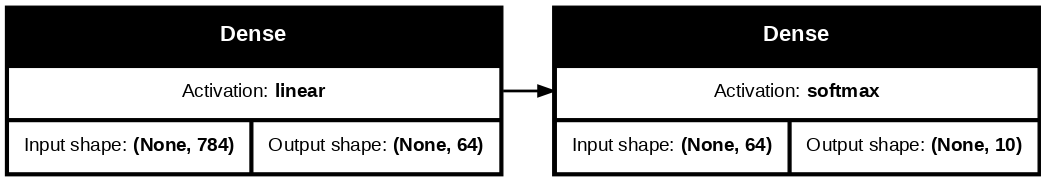

In [ ]:

def dffn(n_inputs, n_outputs):
  model = tf.keras.models.Sequential()
  model.add(Input((n_inputs,)))
  model.add(Dense(64))
  model.add(Dense(n_outputs,activation="softmax"))
  return model

model = dffn(X_train.shape[1], y_train_oh.shape[1])
model.summary()
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.1), loss="categorical_crossentropy")
plot_model(model, show_shapes=True, show_layer_names=False, show_layer_activations=True,rankdir='LR',dpi=100)

In [ ]:
model.fit(X_train, y_train_oh, epochs = 10, batch_size = 100, verbose = 2)
y_pred = model.predict(X_test)

pred_classes = np.argmax(y_pred, axis=1)
print(f'Confusion matrix:\n{confusion_matrix(y_test, pred_classes)}')
print(f'Accuracy: {accuracy_score(y_test, pred_classes):6.4f}')
print(f'Precision: {precision_score(y_test, pred_classes, average="macro"):6.4f}')
print(f'Recall: {recall_score(y_test, pred_classes, average="macro"):6.4f}')
print(f'F1: {f1_score(y_test, pred_classes, average="macro"):6.4f}')

Epoch 1/10
600/600 - 2s - 4ms/step - loss: 4.0032
Epoch 2/10
600/600 - 1s - 2ms/step - loss: 5.7029
Epoch 3/10
600/600 - 3s - 5ms/step - loss: 5.9544
Epoch 4/10
600/600 - 2s - 3ms/step - loss: 7.0999
Epoch 5/10
600/600 - 1s - 2ms/step - loss: 6.3926
Epoch 6/10
600/600 - 3s - 4ms/step - loss: 6.7639
Epoch 7/10
600/600 - 3s - 4ms/step - loss: 7.3404
Epoch 8/10
600/600 - 1s - 2ms/step - loss: 7.1077
Epoch 9/10
600/600 - 3s - 5ms/step - loss: 6.9113
Epoch 10/10
600/600 - 2s - 3ms/step - loss: 6.3872
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Confusion matrix:
[[ 929    0    4    8    1   12    2    7   11    6]
 [   0 1123    4    2    0    1    3    1    1    0]
 [   6   13  917   22    3    5    4   20   34    8]
 [   4    4   23  917    1   13    0   13   33    2]
 [   1   23    7   10  644   13    1   47   31  205]
 [   6    6    8   78    1  628    4    4  146   11]
 [  12   14   39    2   10   56  772    5   41    7]
 [   0   13   11   11    1    1    0  949    6   36]
 [   3   29   18

# Classification using a network with two hidden layers

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_5 (Dense)                 │ (None, 16)             │        12,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         1,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,298 (55.85 KB)

 Trainable params: 14,298 (55.85 KB)

 Non-trainable params: 0 (0.00 B)

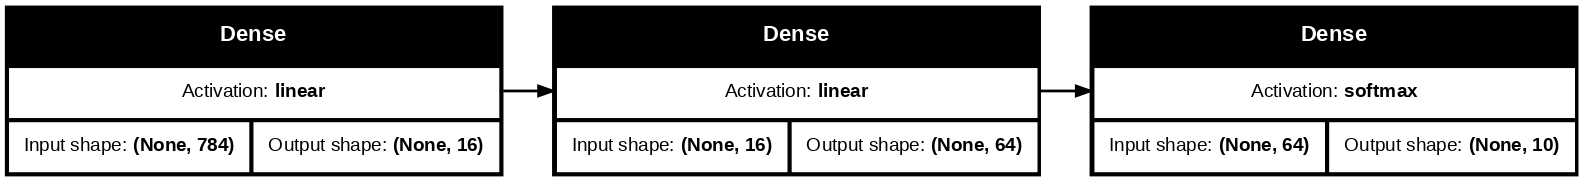

In [ ]:
def dffn_2(n_inputs, n_outputs):
  model = tf.keras.models.Sequential()
  model.add(Input((n_inputs,)))
  model.add(Dense(16))
  model.add(Dense(64))
  model.add(Dense(n_outputs,activation="softmax"))
  return model

model2 = dffn_2(X_train.shape[1], y_train_oh.shape[1])
model2.summary()
model2.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.1), loss="categorical_crossentropy")
plot_model(model2, show_shapes=True, show_layer_names=False, show_layer_activations=True,rankdir='LR',dpi=100)

In [ ]:
model2.fit(X_train, y_train_oh, epochs = 10, batch_size = 100, verbose = 2)
y_pred = model2.predict(X_test)

pred_classes = np.argmax(y_pred, axis=1)
print(f'Confusion matrix:\n{confusion_matrix(y_test, pred_classes)}')
print(f'Accuracy: {accuracy_score(y_test, pred_classes):6.4f}')
print(f'Precision: {precision_score(y_test, pred_classes, average="macro"):6.4f}')
print(f'Recall: {recall_score(y_test, pred_classes, average="macro"):6.4f}')
print(f'F1: {f1_score(y_test, pred_classes, average="macro"):6.4f}')

Epoch 1/10
600/600 - 1s - 2ms/step - loss: 0.6695
Epoch 2/10
600/600 - 1s - 2ms/step - loss: 1.1808
Epoch 3/10
600/600 - 1s - 2ms/step - loss: 126.6037
Epoch 4/10
600/600 - 1s - 2ms/step - loss: 2.3471
Epoch 5/10
600/600 - 1s - 2ms/step - loss: 0.7851
Epoch 6/10
600/600 - 1s - 2ms/step - loss: 0.5317
Epoch 7/10
600/600 - 2s - 3ms/step - loss: 0.4961
Epoch 8/10
600/600 - 2s - 3ms/step - loss: 0.7247
Epoch 9/10
600/600 - 1s - 2ms/step - loss: 3.6750
Epoch 10/10
600/600 - 1s - 2ms/step - loss: 0.8112
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Confusion matrix:
[[ 966    0    1    1    0    4    1    4    2    1]
 [   0 1114    6    2    1    5    2    0    4    1]
 [  11    6  893   36   11    4    5   10   52    4]
 [   7    2   13  902    5   22    0   17   34    8]
 [   3    9   14    4  886    2    5    2    7   50]
 [  32    2    6   60    7  740    1    4   29   11]
 [  17    5   54    5   12   35  828    1    0    1]
 [   4    8   25    6   10    2    0  863    2  108]
 [   9   22   